c:\Users\Eva\CBP2_Shared_Housing_Model\.venv\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)



Final model row:
                               900
effective_studio_cost  1381.198307
studio_units            861.000000
shared_units            786.000000
studio_rent            1381.198307
shared_rent            1000.000000
students_in_studio      719.000000
students_in_shared      781.000000
students_unhoused       500.000000
share_matched             0.689000
avg_mismatch              0.311000
avg_loneliness            0.726191
studio_allowance_cost     0.000000
total_public_cost         0.000000
vacancy_studio            0.164925
vacancy_shared            0.006361
withdrawn_studios         0.000000
withdrawn_shared          0.000000
built_studios             0.000000
built_shared              1.000000
scarcity_studio           0.562137
scarcity_shared           0.175573


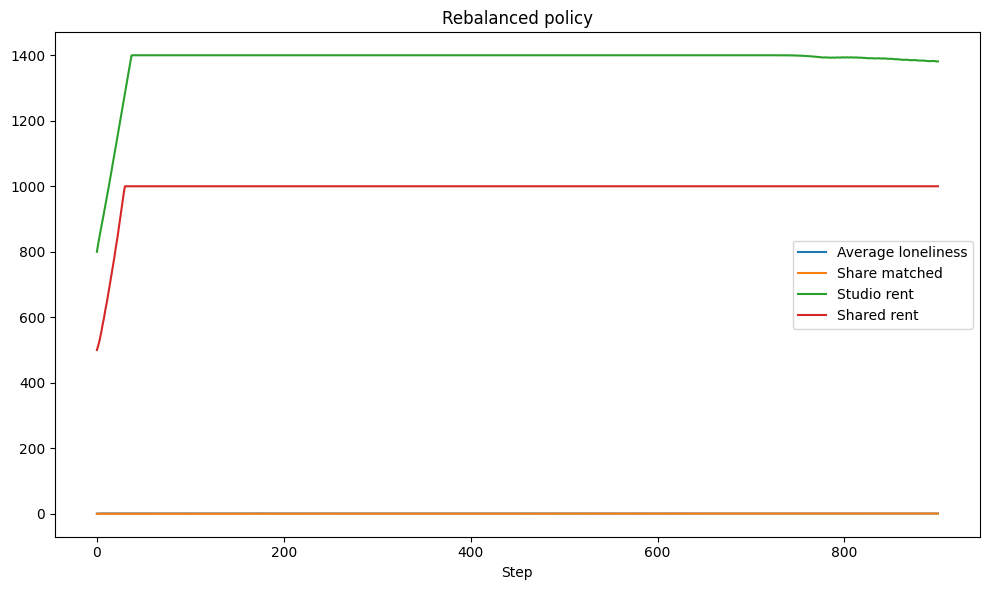

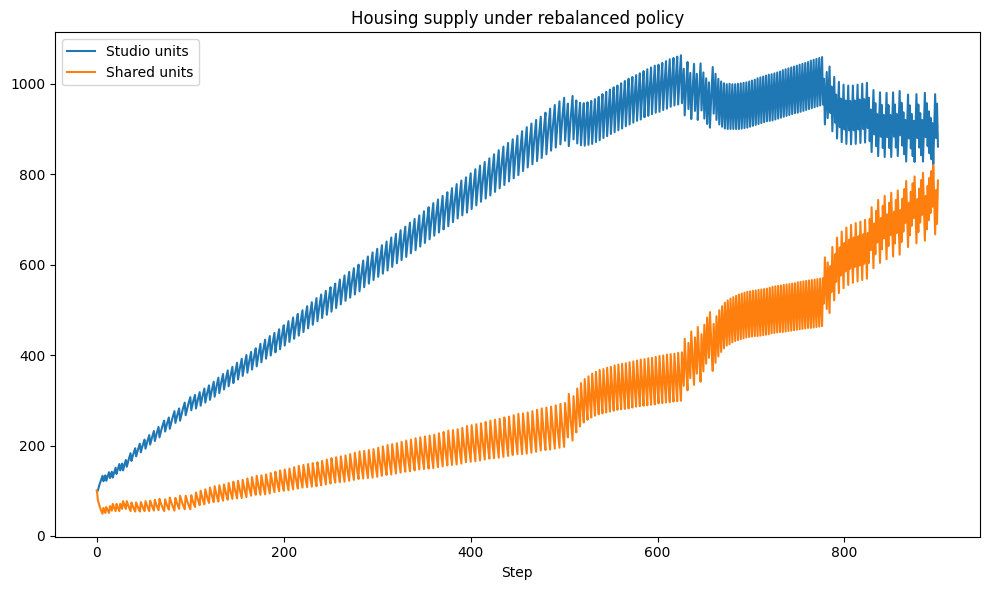

c:\Users\Eva\CBP2_Shared_Housing_Model\.venv\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)



Scenario comparison:
                 scenario  studio_units  shared_units  studio_rent  \
0   studio_subsidy_absent         224.0         132.0        400.0   
1  studio_subsidy_present         236.0         117.0        400.0   

   shared_rent  effective_studio_cost  students_in_studio  students_in_shared  \
0   299.220068                  400.0               189.0               111.0   
1   292.963165                  200.0               189.0               111.0   

   students_unhoused  share_matched  avg_mismatch  avg_loneliness  \
0                0.0            1.0           0.0            0.63   
1                0.0            1.0           0.0            0.63   

   total_public_cost  
0                0.0  
1            37800.0  


In [4]:
from __future__ import annotations

from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mesa
from mesa.datacollection import DataCollector

# =========================================================
# Student income generation helper (NEW - Simona)
# =========================================================

# Source: database.eurostudent.eu
INCOME_DECILE_MAX_VALUES = [
    780, 1000, 1150, 1301.67, 1461.67,
    1618.33, 1810, 2055, 2425, 6556.67
]

INCOME_DECILE_MEAN_VALUES = [
    567.24, 893.87, 1074.81, 1228.65, 1384.45,
    1537.44, 1716.70, 1930.14, 2229.87, 2983.56
]


# TODO nice comment here
def generate_student_incomes(n_agents, max_values, mean_values, min_income=0, seed=None, concentration=8):
    rng = np.random.default_rng(seed)

    max_values = np.array(max_values, dtype=float)
    mean_values = np.array(mean_values, dtype=float)

    lower_bounds = np.concatenate(([min_income], max_values[:-1]))
    upper_bounds = max_values

    incomes = []

    base_count = n_agents // 10
    remainder = n_agents % 10

    for i in range(10):
        count = base_count + (1 if i < remainder else 0)

        low = lower_bounds[i]
        high = upper_bounds[i]
        mean = mean_values[i]

        relative_mean = (mean - low) / (high - low)
        relative_mean = np.clip(relative_mean, 0.01, 0.99)

        alpha = relative_mean * concentration
        beta = (1 - relative_mean) * concentration

        samples = rng.beta(alpha, beta, size=count)
        decile_incomes = low + samples * (high - low)

        incomes.extend(decile_incomes)

    incomes = np.array(incomes)
    rng.shuffle(incomes)

    return incomes


# =========================================================
# STUDENT AGENT
# =========================================================

class StudentAgent(mesa.Agent):
    """
    Student agent in a non-spatial housing market.

    Key idea:
    - each student has a preferred housing type
    - each step they must choose the best feasible option available now
    - loneliness evolves from mismatch, isolation, and financial stress
    """

    def __init__(
        self,
        model: "StudentHousingModel",
        income: float,
        privacy_pref: float,
        social_need: float,
        time_pressure: float,
        loneliness_sensitivity: float,
        stress_sensitivity: float,
    ):
        super().__init__(model)

        self.income = income
        self.privacy_pref = privacy_pref
        self.social_need = social_need
        self.time_pressure = time_pressure
        self.loneliness_sensitivity = loneliness_sensitivity
        self.stress_sensitivity = stress_sensitivity

        self.housing_preference = (
            "shared" if self.social_need - self.privacy_pref > 0.1 else "studio"
        )

        self.current_housing = "none"
        self.mismatch = 0.0
        self.loneliness = 0.4

        # useful for diagnostics
        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

    def step(self) -> None:
        """
        Students do not automatically re-enter the housing market every step.
        If already housed, they may stay unless mismatched and willing/able to move.
        """

        # If already housed and matched, stay put
        if self.current_housing != "none" and self.current_housing == self.housing_preference:
            if self.current_housing == "studio":
                self.model.realized_demand_studio += 1
            elif self.current_housing == "shared":
                self.model.realized_demand_shared += 1
            return

        # If already housed but mismatched, only some try to move
        if self.current_housing != "none" and self.current_housing != self.housing_preference:
            if self.model.random.random() > self.model.move_probability:
                if self.current_housing == "studio":
                    self.model.realized_demand_studio += 1
                elif self.current_housing == "shared":
                    self.model.realized_demand_shared += 1
                return

        # If unhoused, or if mismatched and trying to move, choose housing
        old_housing = self.current_housing
        choice = self.choose_housing()

        # Free up old unit if moving away from it
        if old_housing == "studio" and choice != "studio":
            self.model.available_studios += 1
        elif old_housing == "shared" and choice != "shared":
            self.model.available_shared += 1

        # Allocate new unit
        if choice == "studio" and self.model.available_studios > 0:
            self.current_housing = "studio"
            self.model.available_studios -= 1
            self.model.realized_demand_studio += 1

        elif choice == "shared" and self.model.available_shared > 0:
            self.current_housing = "shared"
            self.model.available_shared -= 1
            self.model.realized_demand_shared += 1

        else:
            self.current_housing = "none"
            self.model.realized_unhoused += 1

    def choose_housing(self) -> str:
        options: dict[str, float] = {}

        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

        # Studio
        if self.model.available_studios > 0:
            effective_studio_cost = max(
                self.model.studio_rent - self.model.studio_rent_allowance,
                0.0,
            )
            if effective_studio_cost <= self.income:
                u_studio = self.utility_studio(effective_studio_cost)
                options["studio"] = u_studio
                self.last_choice_utility_studio = u_studio

        # Shared
        if self.model.available_shared > 0:
            effective_shared_cost = self.model.shared_rent
            if effective_shared_cost <= self.income:
                u_shared = self.utility_shared(effective_shared_cost)
                options["shared"] = u_shared
                self.last_choice_utility_shared = u_shared

        # Forced-choice constraint:
        # if at least one real option exists, choose the best one.
        if options:
            return max(options, key=options.get)

        # Only fallback if nothing is feasible.
        return "none"

    def utility_studio(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "studio" else -0.6
        privacy_benefit = self.privacy_pref
        social_penalty = -0.8 * self.social_need
        scarcity_penalty = -0.20 * self.model.scarcity_studio
        time_bonus = 0.10 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + 0.8 * privacy_benefit
            + social_penalty
            + scarcity_penalty
            + time_bonus
        )

    def utility_shared(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "shared" else -0.6
        social_benefit = self.social_need
        privacy_penalty = -0.7 * self.privacy_pref
        scarcity_penalty = -0.20 * self.model.scarcity_shared
        coordination_penalty = -0.08 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + social_benefit
            + privacy_penalty
            + scarcity_penalty
            + coordination_penalty
        )

    def advance_wellbeing(self) -> None:
        """
        Loneliness update after housing allocation.
        """
        self.mismatch = 0.0 if self.current_housing == self.housing_preference else 1.0

        if self.current_housing == "studio":
            housing_cost = max(
                self.model.studio_rent - self.model.studio_rent_allowance,
                0.0,
            )
            isolation = 0.5
            routine_interaction = 0.10

        elif self.current_housing == "shared":
            housing_cost = self.model.shared_rent
            isolation = 0.10
            routine_interaction = 0.5

        else:
            housing_cost = self.income * 0.5
            isolation = 0.5
            routine_interaction = 0.02

        rent_burden = housing_cost / max(self.income, 1.0)
        stress = max(rent_burden - 0.35, 0.0)

        delta = (
            0.12 * self.loneliness_sensitivity * self.mismatch
            + 0.10 * isolation
            + 0.10 * self.stress_sensitivity * stress
            - 0.12 * routine_interaction
        )

        self.loneliness = min(max(self.loneliness + delta, 0.0), 1.0)


# =========================================================
# MODEL
# =========================================================

class StudentHousingModel(mesa.Model):
    """
    Mesa ABM for student housing and loneliness with:

    - forced short-term housing choice
    - endogenous rents
    - developer entry/build response
    - investor withdrawal when profitability is negative
    """

    def __init__(
        self,
        n_students: int = 300,
        initial_studios: int = 120,
        move_probability: float = 0.25,
        initial_shared: int = 90,
        studio_rent: float = 750.0,
        shared_rent: float = 500.0,
        studio_build_cost: float = 720.0,
        shared_build_cost: float = 520.0,
        studio_rent_allowance: float = 300.0,
        investor_withdrawal_rate: float = 0.05,
        rent_adjustment_speed: float = 0.08,
        vacancy_sensitivity: float = 0.06,
        min_studio_rent: float = 400.0,
        max_studio_rent: float = 1400.0,
        min_shared_rent: float = 250.0,
        max_shared_rent: float = 1000.0,
        min_income_threshold: float = 225.0,    #NEW (JUSTIFY!!! ANNA)
        conversion_rate: float = 0.10,          #NEW
        studio_rent_eq: float = 750.0,          # ← NEW
        shared_rent_eq: float = 500.0,          # ← NEW
        gamma_studio: float = 0.03,              # ← NEW
        gamma_shared: float = 0.03,              # ← NEW
        natural_vacancy_studio: float = 0.05,   # ← NEW
        natural_vacancy_shared: float = 0.05,   # NEW
        kappa_buffer_pct: float = 0.20,   # NEW (20% of build cost, upper end of 15–25% range)
        seed: Optional[int] = 42,
    ):
        super().__init__(seed=seed)

        # -----------------------------
        # Stock
        # -----------------------------
        self.studio_units = initial_studios
        self.shared_units = initial_shared

        # -----------------------------
        # Prices
        # -----------------------------
        self.studio_rent = studio_rent
        self.shared_rent = shared_rent

        self.min_studio_rent = min_studio_rent
        self.max_studio_rent = max_studio_rent
        self.min_shared_rent = min_shared_rent
        self.max_shared_rent = max_shared_rent

        self.rent_adjustment_speed = rent_adjustment_speed
        self.vacancy_sensitivity = vacancy_sensitivity

        # -------------
        # Landlord conversion           ← NEW SECTION
        # -----------------------------
        self.min_income_threshold = min_income_threshold
        self.conversion_rate = conversion_rate

        # Equilibrium parameters        ← NEW SECTION
        # -----------------------------
        self.studio_rent_eq = studio_rent_eq
        self.shared_rent_eq = shared_rent_eq
        self.natural_vacancy_studio = natural_vacancy_studio
        self.natural_vacancy_shared = natural_vacancy_shared
        
        # -----------------------------
        # Cost structure
        # -----------------------------
        self.studio_build_cost = studio_build_cost
        self.shared_build_cost = shared_build_cost

        # -----------------------------
        # Developer trigger parameters  ← NEW SECTION
        # -----------------------------
        # Buffer set at 20% of build cost, upper end of empirical range (15-25%).
        # Reflects structural disincentives to rental construction in Dutch market.
        # Kappa reflects whether the rent covers the cost of new building + buffer (profit margin needs to be wide)
        self.kappa_buffer_pct = kappa_buffer_pct
        self.kappa_studio = (self.studio_build_cost - self.studio_rent_eq) + (kappa_buffer_pct * self.studio_build_cost)
        self.kappa_shared = (self.shared_build_cost - self.shared_rent_eq) + (kappa_buffer_pct * self.shared_build_cost)
        self.gamma_studio = gamma_studio
        self.gamma_shared = gamma_shared

        # -----------------------------
        # Policy
        # -----------------------------
        self.studio_rent_allowance = studio_rent_allowance
        self.investor_withdrawal_rate = investor_withdrawal_rate

        # -----------------------------
        # Dynamic counters
        # -----------------------------
        self.available_studios = self.studio_units
        self.available_shared = self.shared_units

        self.scarcity_studio = 0.0
        self.scarcity_shared = 0.0

        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0

        self.last_vacancy_studio = 0.0
        self.last_vacancy_shared = 0.0

        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # Previous-step latent demand proxies
        self.latency_demand_studio = initial_studios
        self.latency_demand_shared = initial_shared

        self.move_probability = move_probability

        # Student incomes
        incomes = generate_student_incomes(
            n_agents=n_students,
            max_values=INCOME_DECILE_MAX_VALUES,
            mean_values=INCOME_DECILE_MEAN_VALUES,
            seed=seed,
        )

        # -----------------------------
        # Create student agents
        # -----------------------------
        for i in range(n_students):
            income = incomes[i]
            privacy_pref = self.random.uniform(0.0, 1.0)
            social_need = self.random.uniform(0.0, 1.0)
            time_pressure = self.random.uniform(0.0, 1.0)
            loneliness_sensitivity = self.random.uniform(0.6, 1.4)
            stress_sensitivity = self.random.uniform(0.6, 1.4)

            StudentAgent(
                self,
                income=income,
                privacy_pref=privacy_pref,
                social_need=social_need,
                time_pressure=time_pressure,
                loneliness_sensitivity=loneliness_sensitivity,
                stress_sensitivity=stress_sensitivity,
            )

        # -----------------------------
        # Data collection
        # -----------------------------
        self.datacollector = DataCollector(
            model_reporters={
                "effective_studio_cost": lambda m: m.studio_rent - m.studio_rent_allowance,
                "studio_units": lambda m: m.studio_units,
                "shared_units": lambda m: m.shared_units,
                "studio_rent": lambda m: m.studio_rent,
                "shared_rent": lambda m: m.shared_rent,
                "students_in_studio": lambda m: m.count_housing("studio"),
                "students_in_shared": lambda m: m.count_housing("shared"),
                "students_unhoused": lambda m: m.count_housing("none"),
                "share_matched": lambda m: m.share_matched(),
                "avg_mismatch": lambda m: m.avg_mismatch(),
                "avg_loneliness": lambda m: m.avg_loneliness(),
                "studio_allowance_cost": lambda m: m.studio_allowance_cost(),
                "total_public_cost": lambda m: m.total_public_cost(),
                "vacancy_studio": lambda m: m.last_vacancy_studio,
                "vacancy_shared": lambda m: m.last_vacancy_shared,
                "withdrawn_studios": lambda m: m.last_withdrawn_studios,
                "withdrawn_shared": lambda m: m.last_withdrawn_shared,
                "built_studios": lambda m: m.last_built_studios,
                "built_shared": lambda m: m.last_built_shared,
                "scarcity_studio": lambda m: m.scarcity_studio,
                "scarcity_shared": lambda m: m.scarcity_shared,
            },
            agent_reporters={
                "housing_preference": "housing_preference",
                "current_housing": "current_housing",
                "mismatch": "mismatch",
                "loneliness": "loneliness",
                "income": "income",
            },
        )

        self.datacollector.collect(self)

    # =====================================================
    # MAIN STEP
    # =====================================================

    def step(self) -> None:
        # Reset counters
        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0
        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # 1. landlords withdraw unprofitable units
        self.landlord_withdrawal()

        # 2. Developers build based on expected profitability
        self.developer_build_decision()

        # 3. Only vacant units are available for this step's allocation
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.available_studios = max(self.studio_units - occupied_studios, 0)
        self.available_shared = max(self.shared_units - occupied_shared, 0)

        # 4. Students choose housing in random order
        self.agents.shuffle_do("step")

        # 5. Update scarcity and vacancy
        self.update_market_state()

        # 6. Endogenous rent adjustment
        self.adjust_rents()

        # 7. Update wellbeing
        for agent in self.agents:
            agent.advance_wellbeing()

        # 8. Collect data
        self.datacollector.collect(self)

    # =====================================================
    # MARKET DYNAMICS
    # =====================================================

    def studio_profit_margin(self) -> float:
        """
        Simplified per-unit operational margin for investors.
        """
        return self.studio_rent - self.studio_operating_cost

    def shared_profit_margin(self) -> float:
        """
        Shared units benefit from object subsidy on the supply side.
        """
        return self.shared_rent - self.shared_operating_cost

    def landlord_withdrawal(self) -> None:
        """
        Landlord decision-making: convert between types or exit market.
        """

        occupancy_studio = self.count_housing("studio") / max(self.studio_units, 1)
        occupancy_shared = self.count_housing("shared") / max(self.shared_units, 1)

        income_studio = self.studio_rent * occupancy_studio
        income_shared = self.shared_rent * occupancy_shared

        if max(income_studio, income_shared) < self.min_income_threshold: 
            # check if there is any units at all
            if self.studio_units < 0: 
                # units are dumped gradually, but at least one for sure
                removed = max(1, int(self.studio_units * self.investor_withdrawal_rate))
                self.studio_units = max(self.studio_units - removed, 0)
                # track how many units are removed
                self.last_withdrawn_studios = removed
        
            if self.shared_units > 0:
                removed = max(1, int(self.shared_units * self.investor_withdrawal_rate))
                self.shared_units = max(self.shared_units - removed, 0)
                self.last_withdrawn_shared = removed
            return
        
        # if income from studios is higher, convert shared units to studios 
        if income_studio > income_shared:
            convert = max(1, int(self.shared_units * self.conversion_rate))
            convert = min(convert, self.shared_units)
            self.shared_units -= convert
            self.studio_units += convert

        # if income from shared housing is higher, convert studios to shared units 
        elif income_shared > income_studio:
            convert = max(1, int(self.studio_units * self.conversion_rate))
            convert = min(convert, self.studio_units)
            self.studio_units -= convert
            self.shared_units += convert

    def developer_build_decision(self) -> None:
        """
        Developers build based on rent and vacancy rate
        """
        for btype in ["studio", "shared"]:
            if btype == "studio":
                rent = self.studio_rent
                rent_eq = self.studio_rent_eq
                kappa = self.kappa_studio
                gamma = self.gamma_studio
                vacancy = self.last_vacancy_studio
                natural_vac = self.natural_vacancy_studio
            else:
                rent = self.shared_rent
                rent_eq = self.shared_rent_eq
                kappa = self.kappa_shared
                gamma = self.gamma_shared
                vacancy = self.last_vacancy_shared
                natural_vac = self.natural_vacancy_shared

            rent_signal = rent - rent_eq          # how far above equilibrium rent 
            vacancy_signal = natural_vac - vacancy # how far from the natural vacancy rate 

            # Both conditions must hold
            if rent_signal > kappa and vacancy_signal > 0:
                new_units = int(gamma * rent_signal * vacancy_signal)
                new_units = max(1, new_units)     # always at least 1 if triggered

                if btype == "studio":
                    self.studio_units += new_units
                    self.last_built_studios += new_units
                else:
                    self.shared_units += new_units
                    self.last_built_shared += new_units

    def update_market_state(self) -> None:
        """
        Update scarcity, vacancy, and latent demand proxies after allocation.
        """
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.last_vacancy_studio = max(self.studio_units - occupied_studios, 0) / max(
            self.studio_units, 1
        )
        self.last_vacancy_shared = max(self.shared_units - occupied_shared, 0) / max(
            self.shared_units, 1
        )

        unmet_studio = sum(
            1
            for a in self.agents
            if a.housing_preference == "studio" and a.current_housing != "studio"
        )
        unmet_shared = sum(
            1
            for a in self.agents
            if a.housing_preference == "shared" and a.current_housing != "shared"
        )

        self.scarcity_studio = unmet_studio / max(self.studio_units, 1)
        self.scarcity_shared = unmet_shared / max(self.shared_units, 1)

        # latent demand proxy carried into next round
        self.latency_demand_studio = occupied_studios + unmet_studio
        self.latency_demand_shared = occupied_shared + unmet_shared

    def adjust_rents(self) -> None:
        """
        Endogenous rent update.

        Rent rises with scarcity / unmet demand and falls with vacancy.
        This is intentionally simple but closes the core market feedback loop.
        """
        studio_growth = (
            # UPWARD PRESSURE (Demand)
            self.rent_adjustment_speed * self.scarcity_studio     # scarcity studio = sum of all the studio that people would want to occupy buy aren't 
            # DOWNWARD PRESSURE (Vacancy)
            - self.vacancy_sensitivity * self.last_vacancy_studio # last_vacancy_studio = empty studios / overall number of studios
        )
        shared_growth = (
            self.rent_adjustment_speed * self.scarcity_shared
            - self.vacancy_sensitivity * self.last_vacancy_shared
        )

        # Target rent based on growth 
        target_studio_rent = self.studio_rent * (1.0 + studio_growth)
        target_shared_rent = self.shared_rent * (1.0 + shared_growth)

        # Apply inertia to avoid sudden jumps of rent (rend adjustment is realistically slower)
        inertia = 0.2
        self.studio_rent = (1 - inertia) * self.studio_rent + inertia * target_studio_rent
        self.shared_rent = (1 - inertia) * self.shared_rent + inertia * target_shared_rent

        # Forces rent to be within the max and min pre-established
        self.studio_rent = min(max(self.studio_rent, self.min_studio_rent), self.max_studio_rent)
        self.shared_rent = min(max(self.shared_rent, self.min_shared_rent), self.max_shared_rent)

    # =====================================================
    # METRICS
    # =====================================================

    def count_housing(self, housing_type: str) -> int:
        return sum(1 for a in self.agents if a.current_housing == housing_type)

    def share_matched(self) -> float:
        return sum(
            1 for a in self.agents if a.current_housing == a.housing_preference
        ) / max(len(self.agents), 1)

    def avg_mismatch(self) -> float:
        return sum(a.mismatch for a in self.agents) / max(len(self.agents), 1)

    def avg_loneliness(self) -> float:
        return sum(a.loneliness for a in self.agents) / max(len(self.agents), 1)

    def studio_allowance_cost(self) -> float:
        return self.count_housing("studio") * self.studio_rent_allowance

    def total_public_cost(self) -> float:
        return self.studio_allowance_cost()


# =========================================================
# HELPERS
# =========================================================

def run_model(
    steps: int = 40,
    **model_kwargs,
) -> tuple[StudentHousingModel, pd.DataFrame, pd.DataFrame]:
    model = StudentHousingModel(**model_kwargs)

    for _ in range(steps):
        model.step()

    model_df = model.datacollector.get_model_vars_dataframe()
    agent_df = model.datacollector.get_agent_vars_dataframe()
    return model, model_df, agent_df


def scenario_dict() -> dict[str, dict]:
    return {
        "studio_subsidy_absent": {
            "studio_rent_allowance": 0.0,
        },
        "studio_subsidy_present": {
            "studio_rent_allowance": 200,
        },
    }


def compare_scenarios(steps: int = 40) -> pd.DataFrame:
    rows = []

    for scenario_name, params in scenario_dict().items():
        _, model_df, _ = run_model(
            steps=steps,
            seed=42,
            **params,
        )

        final = model_df.iloc[-1].to_dict()
        final["scenario"] = scenario_name
        rows.append(final)

    if not rows:
        raise ValueError("No scenarios found. Check that scenario_dict() returns a non-empty dictionary.")

    comparison = pd.DataFrame(rows)

    cols = [
        "scenario",
        "studio_units",
        "shared_units",
        "studio_rent",
        "shared_rent",
        "effective_studio_cost",
        "students_in_studio",
        "students_in_shared",
        "students_unhoused",
        "share_matched",
        "avg_mismatch",
        "avg_loneliness",
        "total_public_cost",
    ]

    return comparison[[c for c in cols if c in comparison.columns]]


def plot_model_trajectory(model_df: pd.DataFrame, title: str = "Model trajectory") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["avg_loneliness"], label="Average loneliness")
    plt.plot(model_df.index, model_df["share_matched"], label="Share matched")
    plt.plot(model_df.index, model_df["studio_rent"], label="Studio rent")
    plt.plot(model_df.index, model_df["shared_rent"], label="Shared rent")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_supply_trajectory(model_df: pd.DataFrame, title: str = "Housing supply") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["studio_units"], label="Studio units")
    plt.plot(model_df.index, model_df["shared_units"], label="Shared units")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# EXAMPLE USAGE
# =========================================================

if __name__ == "__main__":
    # Single scenario run
    model, model_df, agent_df = run_model(
        steps=900,
        n_students=2000,
        initial_studios=100,
        initial_shared=100,
        studio_rent=800,
        shared_rent=500.0,
        studio_build_cost=720.0,
        shared_build_cost=520.0,
        studio_rent_allowance=0,
        investor_withdrawal_rate=0.2,
        rent_adjustment_speed=0.01,
        vacancy_sensitivity=0.03,
        # - new parameters, explicit defaults -
        min_income_threshold=225.0,
        conversion_rate=0.10,
        studio_rent_eq=800.0,       
        shared_rent_eq=500.0,       
        gamma_studio=0.03,      
        gamma_shared=0.03,
        natural_vacancy_studio=0.05,
        natural_vacancy_shared=0.05,
        kappa_buffer_pct=0.20,
        seed=42,
    )

    print("\nFinal model row:")
    print(model_df.tail(1).T)

    plot_model_trajectory(model_df, title="Rebalanced policy")
    plot_supply_trajectory(model_df, title="Housing supply under rebalanced policy")

    comparison = compare_scenarios(steps=900)
    print("\nScenario comparison:")
    print(comparison)